In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew, kurtosis

from pytorch_ood.detector import KNN, Mahalanobis, GMM
from pytorch_ood.utils import OODMetrics

In [3]:
Z_id= torch.load("VersaMammo_ZGT_allmasses")
N_fit=int(Z_id.shape[0]*0.8)
Z_id_test=Z_id[N_fit:, :]
Z_id=Z_id[:N_fit, :]

Z_ood= torch.load("VersaMammo_ZGT_nomasses")

Y_id=torch.zeros(Z_id.shape[0])
y_ood=-torch.ones(Z_ood.shape[0])

In [15]:
Z_id= torch.load("medSAM_LoRA_ZGT_allmasses")
N_fit=int(Z_id.shape[0]*0.8)
Z_id_test=Z_id[N_fit:, :]
Z_id=Z_id[:N_fit, :]

Z_ood= torch.load("medSAM_LoRA_ZGT_nomasses")

Y_id=torch.zeros(Z_id.shape[0])
y_ood=-torch.ones(Z_ood.shape[0])

In [16]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# -----------------------------
# 1) Convert features to numpy
# -----------------------------
X_id = Z_id.detach().cpu().numpy()      # [N_id, C]
y_id = Y_id.detach().cpu().numpy()      # [N_id]

X_ood = Z_ood.detach().cpu().numpy()    # [N_ood, C]

# If you have OOD labels, use them here.
# Example:
y_ood = y_ood.detach().cpu().numpy()

# If you do NOT have OOD labels, assign a placeholder label.
# This is only for plotting/coloring if needed.
# y_ood = np.full(shape=(X_ood.shape[0],), fill_value=-1)

# -----------------------------------------
# 2) Concatenate so t-SNE sees both together
# -----------------------------------------
X_all = np.concatenate([X_id, X_ood], axis=0)
y_all = np.concatenate([y_id, y_ood], axis=0)

# Keep track of domain: ID vs OOD
domain_all = np.concatenate([
    np.zeros(X_id.shape[0], dtype=int),   # 0 = ID
    np.ones(X_ood.shape[0], dtype=int),   # 1 = OOD
])

# -----------------------------
# 3) Optional PCA before t-SNE
# -----------------------------
n_pca = min(50, X_all.shape[1], X_all.shape[0])
X_reduced = PCA(n_components=n_pca, random_state=42).fit_transform(X_all)

# -----------------------------
# 4) Run t-SNE
# -----------------------------
X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42,
).fit_transform(X_reduced)

# Split back
X_tsne_id = X_tsne[domain_all == 0]
X_tsne_ood = X_tsne[domain_all == 1]

y_id_plot = y_all[domain_all == 0]
y_ood_plot = y_all[domain_all == 1]

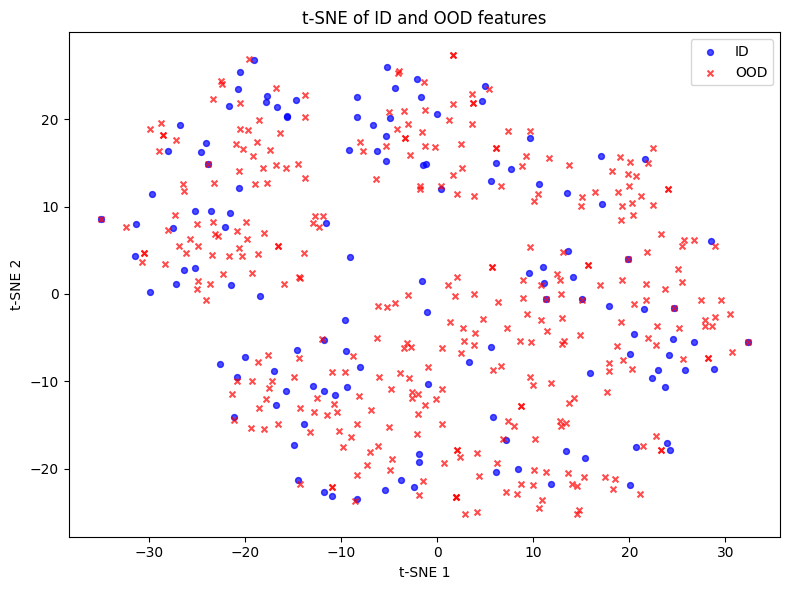

In [17]:
plt.figure(figsize=(8, 6))

# ID points
scatter_id = plt.scatter(
    X_tsne_id[:, 0],
    X_tsne_id[:, 1],
    color="blue",
    alpha=0.7,
    s=18,
    label="ID"
)

# OOD points
scatter_ood = plt.scatter(
    X_tsne_ood[:, 0],
    X_tsne_ood[:, 1],
    color="red",
    alpha=0.7,
    s=18,
    marker="x",
    label="OOD"
)

plt.title("t-SNE of ID and OOD features")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
detector = Mahalanobis(encoder=None)
detector.fit_features(Z_id, Y_id)

scores_id_mds = detector.predict_features(Z_id_test)
scores_ood_mds = detector.predict_features(Z_ood)


y_id  = torch.zeros(len(scores_id_mds), dtype=torch.long)        # ID label = 0
y_ood = -torch.ones(len(scores_ood_mds), dtype=torch.long)       # OOD label = -1

# 2) Concatenate
scores_mds = torch.cat([scores_id_mds.detach().cpu(), scores_ood_mds.detach().cpu()], dim=0)
y_true = torch.cat([y_id, y_ood], dim=0)

# 3) Compute metrics
metrics = OODMetrics()
metrics.update(scores_mds, y_true)
result = metrics.compute()

print(result)

{'AUROC': 0.5580223798751831, 'AUTC': 0.48327094316482544, 'AUPR-IN': 0.1245364248752594, 'AUPR-OUT': 0.9559117555618286, 'FPR95TPR': 0.9375}


In [19]:
detector = KNN(encoder=None)
detector.fit_features(Z_id, Y_id)

scores_id_knn = detector.predict_features(Z_id_test)
scores_ood_knn = detector.predict_features(Z_ood)


y_id  = torch.zeros(len(scores_id_knn), dtype=torch.long)        # ID label = 0
y_ood = -torch.ones(len(scores_ood_knn), dtype=torch.long)       # OOD label = -1

# 2) Concatenate
scores_knn = torch.cat([scores_id_knn.detach().cpu(), scores_ood_knn.detach().cpu()], dim=0)
y_true = torch.cat([y_id, y_ood], dim=0)

# 3) Compute metrics
metrics = OODMetrics()
metrics.update(scores_knn, y_true)
result = metrics.compute()

print(result)

{'AUROC': 0.596501886844635, 'AUTC': 0.46944889426231384, 'AUPR-IN': 0.15997911989688873, 'AUPR-OUT': 0.9299501180648804, 'FPR95TPR': 0.875}


In [20]:
detector = GMM(encoder=None)
detector.fit_features(Z_id, Y_id)

scores_id_gmm = detector.predict_features(Z_id_test)
scores_ood_gmm = detector.predict_features(Z_ood)


y_id  = torch.zeros(len(scores_id_gmm), dtype=torch.long)        # ID label = 0
y_ood = -torch.ones(len(scores_ood_gmm), dtype=torch.long)       # OOD label = -1

# 2) Concatenate
scores_gmm = torch.cat([scores_id_gmm.detach().cpu(), scores_ood_gmm.detach().cpu()], dim=0)
y_true = torch.cat([y_id, y_ood], dim=0)

# 3) Compute metrics
metrics = OODMetrics()
metrics.update(scores_gmm, y_true)
result = metrics.compute()

print(result)

{'AUROC': 0.6150186657905579, 'AUTC': 0.4789878726005554, 'AUPR-IN': 0.12183886766433716, 'AUPR-OUT': 0.9456429481506348, 'FPR95TPR': 0.875}


In [9]:
import numpy as np
from sklearn.metrics import roc_auc_score

def auroc_sklearn(id_scores, ood_scores, higher_is_ood=True):
    id_scores = np.asarray(id_scores).ravel()
    ood_scores = np.asarray(ood_scores).ravel()

    y_true = np.r_[np.zeros(len(id_scores)), np.ones(len(ood_scores))]
    scores = np.r_[id_scores, ood_scores]

    if not higher_is_ood:
        scores = -scores

    return roc_auc_score(y_true, scores)

print(auroc_sklearn(scores_id_mds, scores_ood_mds))

0.5375932835820896


In [67]:
from torchmetrics.functional.classification import binary_auroc

# Convert labels explicitly
# OOD = 1, ID = 0
target = (y_true == -1).long()

auc_raw = binary_auroc(scores_mds.float(), target)
auc_neg = binary_auroc((-scores_mds).float(), target)

print("AUROC raw scores:", auc_raw.item())
print("AUROC negated scores:", auc_neg.item())

AUROC raw scores: 0.625
AUROC negated scores: 0.0


In [69]:
import torch
from torchmetrics.classification import BinaryAUROC

scores = torch.tensor(np.r_[scores_id_mds, scores_ood_mds], dtype=torch.float32)
target = torch.tensor(np.r_[np.zeros(len(scores_id_mds)), np.ones(len(scores_ood_mds))], dtype=torch.long)

metric = BinaryAUROC()
print(metric(scores, target).item())

0.625


In [70]:
import torch
from torchmetrics.functional.classification import binary_auroc

def auroc_torchmetrics_from_distances(id_scores, ood_scores, higher_is_ood=True):
    scores = torch.tensor(
        list(id_scores) + list(ood_scores),
        dtype=torch.float64,
    )
    target = torch.tensor(
        [0] * len(id_scores) + [1] * len(ood_scores),
        dtype=torch.long,
    )

    if not higher_is_ood:
        scores = -scores

    # prevent TorchMetrics from interpreting distances as logits
    scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)

    return binary_auroc(scores, target).item()

print(auroc_torchmetrics_from_distances(scores_id_mds, scores_ood_mds))

1.0


In [68]:
import numpy as np

def auroc_rank(id_scores, ood_scores, higher_is_ood=True):
    """
    AUROC = P(score_ood > score_id) + 0.5 * P(score_ood == score_id)

    id_scores: scores for in-distribution samples
    ood_scores: scores for OOD samples
    higher_is_ood: set False if smaller distance/score means more OOD
    """
    id_scores = np.asarray(id_scores).ravel()
    ood_scores = np.asarray(ood_scores).ravel()

    scores = np.r_[id_scores, ood_scores]
    labels = np.r_[np.zeros(len(id_scores)), np.ones(len(ood_scores))]

    if not higher_is_ood:
        scores = -scores

    order = np.argsort(scores)
    sorted_scores = scores[order]

    ranks = np.empty(len(scores), dtype=float)
    i = 0
    while i < len(scores):
        j = i
        while j + 1 < len(scores) and sorted_scores[j + 1] == sorted_scores[i]:
            j += 1
        avg_rank = (i + 1 + j + 1) / 2.0
        ranks[order[i:j + 1]] = avg_rank
        i = j + 1

    n_pos = len(ood_scores)
    n_neg = len(id_scores)

    if n_pos == 0 or n_neg == 0:
        raise ValueError("Need at least one ID and one OOD sample.")

    rank_sum_pos = ranks[labels == 1].sum()
    auc = (rank_sum_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)

    return float(auc)

print(auroc_rank(scores_id_mds, scores_ood_mds))

1.0


Important caveat

If your actual Mahalanobis score is computed in the original D-dimensional space, then fitting the Gaussian after PCA is only an approximation.

A better projection is:

Fit Gaussian in original feature space.
Sample synthetic points from that Gaussian.
Project both real points and Gaussian samples into PCA or t-SNE.
Plot the samples as the “blob.”


/tmp/ipykernel_334/2481816058.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_gauss = np.random.multivariate_normal(mu, cov, size=5000)


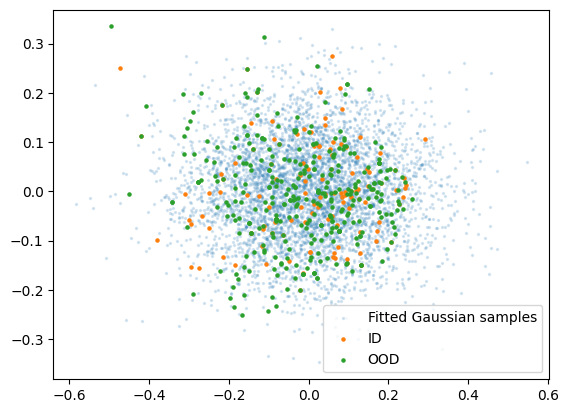

In [27]:
mu = Z_id.mean(axis=0)
cov = np.cov(Z_id.T)

X_gauss = np.random.multivariate_normal(mu, cov, size=5000)

pca = PCA(n_components=2)
X2_id = pca.fit_transform(Z_id)
X2_ood = pca.transform(Z_ood)
X2_gauss = pca.transform(X_gauss)

plt.scatter(X2_gauss[:,0], X2_gauss[:,1], s=2, alpha=0.15, label="Fitted Gaussian samples")
plt.scatter(X2_id[:,0], X2_id[:,1], s=5, label="ID")
plt.scatter(X2_ood[:,0], X2_ood[:,1], s=5, label="OOD")
plt.legend()
plt.show()

This is misleading because it effectively shows separation in only 2 (PCA) dimensions. There is no way of knowing if this separation acutally holds for the entire feature space, where the ID and OOD reside.


Let's have a look at histograms of scores between the two methods: Mahalanobis and KNN and see the kind of separability they achieve:

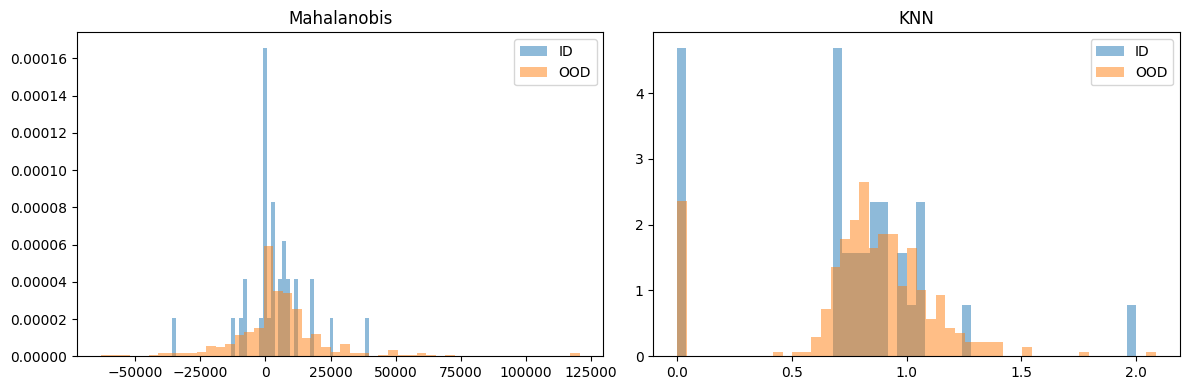

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Mahalanobis
axes[0].hist(scores_id_mds, bins=50, density=True, alpha=0.5, label="ID")
axes[0].hist(scores_ood_mds, bins=50, density=True, alpha=0.5, label="OOD")
axes[0].set_title("Mahalanobis")
axes[0].legend()

# KNN
axes[1].hist(scores_id_knn, bins=50, density=True, alpha=0.5, label="ID")
axes[1].hist(scores_ood_knn, bins=50, density=True, alpha=0.5, label="OOD")
axes[1].set_title("KNN")
axes[1].legend()

# # KNN
# axes[2].hist(scores_id_gmm, bins=50, density=True, alpha=0.5, label="ID")
# axes[2].hist(scores_ood_gmm, bins=50, density=True, alpha=0.5, label="OOD")
# axes[2].set_title("GMM")
# axes[2].legend()

plt.tight_layout()
plt.show()

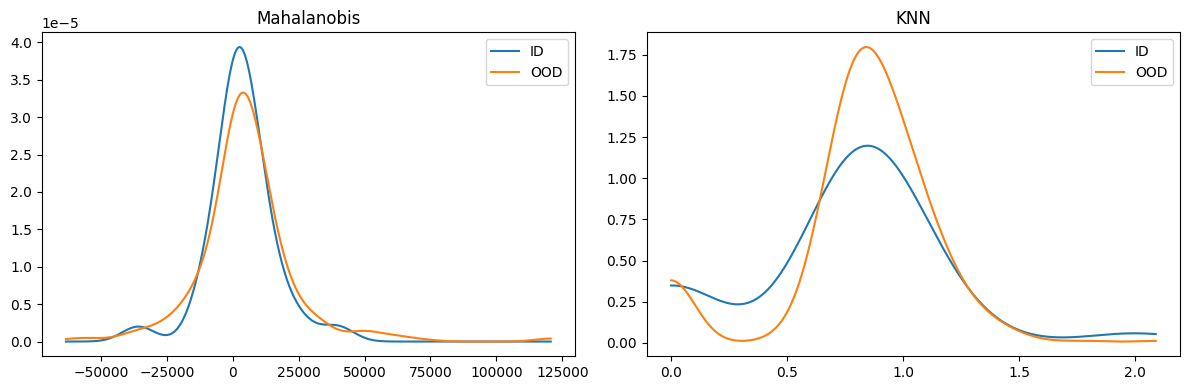

In [11]:
from scipy.stats import gaussian_kde

def plot_kde(ax, id_scores, ood_scores, title):
    x = np.linspace(
        min(id_scores.min(), ood_scores.min()),
        max(id_scores.max(), ood_scores.max()),
        1000
    )

    ax.plot(x, gaussian_kde(id_scores)(x), label="ID")
    ax.plot(x, gaussian_kde(ood_scores)(x), label="OOD")
    ax.set_title(title)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_kde(axes[0], scores_id_mds, scores_ood_mds, "Mahalanobis")
plot_kde(axes[1], scores_id_knn, scores_ood_knn, "KNN")

plt.tight_layout()
plt.show()

/tmp/ipykernel_275/1351945007.py:4: RuntimeWarning: invalid value encountered in log10
  np.log10(scores_id_mds + 1e-8),
/tmp/ipykernel_275/1351945007.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.log10(scores_id_mds + 1e-8),
/tmp/ipykernel_275/1351945007.py:11: RuntimeWarning: invalid value encountered in log10
  np.log10(scores_ood_mds + 1e-8),
/tmp/ipykernel_275/1351945007.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.log10(scores_ood_mds + 1e-8),


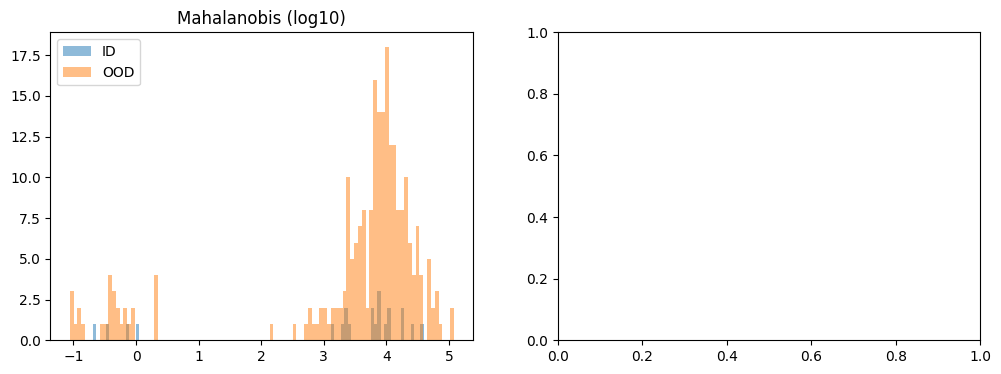

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(
    np.log10(scores_id_mds + 1e-8),
    bins=100,
    alpha=0.5,
    label="ID"
)

axes[0].hist(
    np.log10(scores_ood_mds + 1e-8),
    bins=100,
    alpha=0.5,
    label="OOD"
)

axes[0].set_title("Mahalanobis (log10)")
axes[0].legend()

/tmp/ipykernel_275/3752635083.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


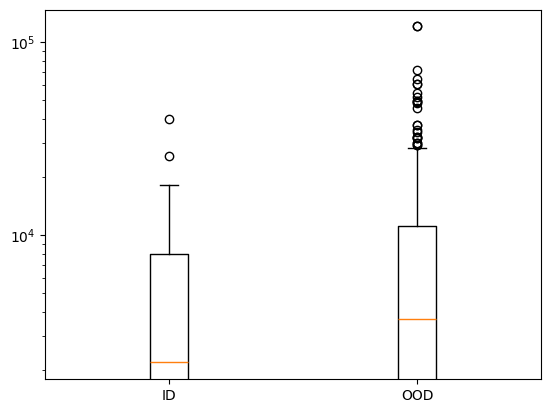

In [13]:
plt.boxplot(
    [scores_id_mds, scores_ood_mds],
    labels=["ID","OOD"]
)
plt.yscale("log")

/tmp/ipykernel_275/2998457077.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


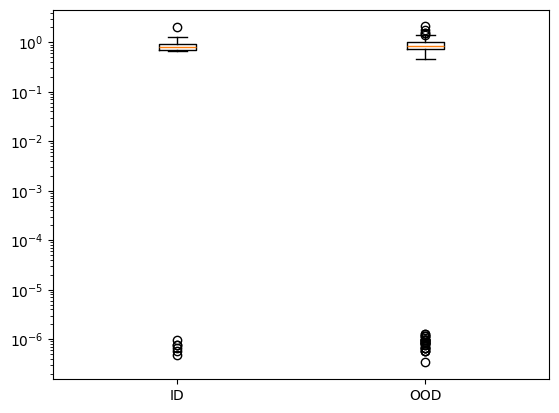

In [14]:
plt.boxplot(
    [scores_id_knn, scores_ood_knn],
    labels=["ID","OOD"]
)
plt.yscale("log")

In [13]:
print(f"scores id percentiles: {np.percentile(scores_id_mds, [1,5,25,50,75,95,99])}")
print(f"scores ood percentiles: {np.percentile(scores_ood_mds, [1,5,25,50,75,95,99])}")

scores id percentiles: [ 0.48435699  0.485507   17.24253273 21.8641758  35.55274487 48.71814938
 52.85044964]
scores ood percentiles: [ 5494.45492187  6400.11210937  7225.95507812  7225.95507812
  7928.82250977 11345.32016602 13757.46291992]


In [14]:
print(f"scores id percentiles: {np.percentile(scores_id_knn, [1,5,25,50,75,95,99])}")
print(f"scores ood percentiles: {np.percentile(scores_ood_knn, [1,5,25,50,75,95,99])}")

scores id percentiles: [0.00000000e+00 2.31807663e-08 1.08771989e-01 1.33629411e-01
 1.56349692e-01 2.01780929e-01 2.17795630e-01]
scores ood percentiles: [1.24864244 1.24864244 1.24864244 1.24864244 1.39073396 1.49878582
 1.6210661 ]


Maybe it got fooled by the test id samples, not by the OOD samples